# Paper example
In this demo we go through the example presented in our paper on this toolbox.

Here, we compare a few representations from the ResNet-50 model against data from the NSD synthetic dataset. We chose this dataset, because it contains only 284 images which group into categorically different images, such that the RDMs may have human understandable structure.

To keep the data-files reasonably small this demo operates on the 1.8mm voxel data preparations. Following the NSD authors recommendation, we use the fithrf version of the betas.

# Getting the data
To run this demo, you will need to download the nsdsynthetic data. To obtain the rights to use these data, please fill in the [NSD Data Access form](https://forms.gle/xue2bCdM9LaFNMeb7). After filling in the form you will be directed to a manual which informs you about data formats, experimental conditions, etc. For this example, the main sections of interest are:

- The documentation [how to download data](https://cvnlab.slite.page/p/dC~rBTjqjb/How-to-get-the-data)
- The documentation of [nsdsynthetic](https://cvnlab.slite.page/p/wLlJyfWRvg/Functional-data-nsdsynthetic)
- The [ROI definitions](https://cvnlab.slite.page/p/X_7BBMgghj/ROIs)

## File download
We need four types of files to work with this dataset as summarized in this table:

| name | origin | local location |
| ---- | ------ | ------------ |
| data | [link](https://natural-scenes-dataset.s3.amazonaws.com/index.html#nsddata_betas/ppdata/subj01/func1pt8mm/nsdsyntheticbetas_fithrf/) | data/subjXX/betas_nsdsynthetic.hdf5 |
| rois | [link](https://natural-scenes-dataset.s3.amazonaws.com/index.html#nsddata/ppdata/subj01/func1pt8mm/roi/prf-visualrois.nii.gz) | rois/subjXX/prf-visualrois.nii.gz |
| exp design | [link](https://natural-scenes-dataset.s3.amazonaws.com/index.html#nsddata/experiments/nsdsynthetic/) | nsdsynthetic |
| stimuli | [link](https://natural-scenes-dataset.s3.amazonaws.com/index.html#nsddata/stimuli/nsdsynthetic/nsdsynthetic/) & [link2](https://natural-scenes-dataset.s3.amazonaws.com/index.html#nsddata/stimuli/nsdsynthetic/nsdsynthetic_subj01/)| stimuli |

We use the .png images as input here, because resnet is trained on standard image files, not on linear luminance values.

You can download the files by running one of the two bash cells below. They also exist as `script_download_nsdsynthetic.sh` and `script_download_nsdsynthetic_aws.sh` in the demos folder to run from a terminal.

Alternatively, you can manually download the files. This will unfortunately require a click for each file.

### using aws-cli
If you have the aws cli installed you can download the files with the following commands:


In [ ]:
%%bash
mkdir paper_example
aws s3 sync s3://natural-scenes-dataset/nsddata/stimuli/nsdsynthetic/nsdsynthetic paper_example/stimuli
aws s3 sync s3://natural-scenes-dataset/nsddata/stimuli/nsdsynthetic/nsdsynthetic_subj01 paper_example/stimuli
aws s3 sync s3://natural-scenes-dataset/nsddata/experiments/nsdsynthetic paper_example/nsdsynthetic
for i in {1..8}; do
  aws s3 cp s3://natural-scenes-dataset/nsddata_betas/ppdata/subj0${i}/func1pt8mm/nsdsyntheticbetas_fithrf/betas_nsdsynthetic.hdf5 paper_example/data/subj0${i}/betas_nsdsynthetic.hdf5;
  aws s3 cp s3://natural-scenes-dataset/nsddata/ppdata/subj0${i}/func1pt8mm/roi/prf-visualrois.nii.gz paper_example/rois/subj0${i}/prf-visualrois.nii.gz;
done

### using curl
This cell downloads the same files (a little slower) using curl

In [ ]:
%%bash
# Create directory structure
mkdir -p paper_example/stimuli
mkdir -p paper_example/nsdsynthetic
mkdir -p paper_example/rois

S3_BUCKET="https://natural-scenes-dataset.s3.amazonaws.com"

# Download synthetic stimuli
echo "Downloading nsdsynthetic stimuli..."
for i in {1..220}; do
  img=$(printf "nsdsynthetic%03d" $i)
curl -L -o paper_example/stimuli/$img.png \
  "$S3_BUCKET/nsddata/stimuli/nsdsynthetic/nsdsynthetic/$img.png" 2>/dev/null
  echo "Downloaded $img"
done
for i in {221..284}; do
  img=$(printf "nsdsynthetic%03d" $i)
curl -L -o paper_example/stimuli/$img.png \
  "$S3_BUCKET/nsddata/stimuli/nsdsynthetic/nsdsynthetic_subj01/$img.png" 2>/dev/null
  echo "Downloaded $img"
done

# Download experimental data
echo "Downloading nsdsynthetic experiments data..."
curl -L -o paper_example/nsdsynthetic/nsdsynthetic_expdesign.mat \
  "$S3_BUCKET/nsddata/experiments/nsdsynthetic/nsdsynthetic_expdesign.mat" 2>/dev/null
curl -L -o paper_example/nsdsynthetic/nsdsyntheticimageinformation.csv \
  "$S3_BUCKET/nsddata/experiments/nsdsynthetic/nsdsyntheticimageinformation.csv" 2>/dev/null

# Download betas and ROIs for subjects 01-08
for i in {1..8}; do
  subj=$(printf "subj%02d" $i)
  mkdir -p paper_example/data/$subj
  mkdir -p paper_example/rois/$subj
  
  echo "Downloading betas for $subj..."
  curl -L -o "paper_example/data/$subj/betas_nsdsynthetic.hdf5" \
    "$S3_BUCKET/nsddata_betas/ppdata/$subj/func1pt8mm/nsdsyntheticbetas_fithrf/betas_nsdsynthetic.hdf5"
  
  echo "Downloading ROI data for $subj..."
  curl -L -o "paper_example/rois/$subj/prf-visualrois.nii.gz" \
    "$S3_BUCKET/nsddata/ppdata/$subj/func1pt8mm/roi/prf-visualrois.nii.gz"
done

echo "Download complete!"


## Imports

In [1]:
# imports

# a few standard libraries
import numpy as np
import pandas as pd
import h5py
import scipy.io as sio
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
import os
import tqdm

# import the RSA toolbox
import rsatoolbox

## the following libraries may need to be installed separately using pip or conda
# libraries for working with fMRI data
import nilearn
import nibabel as nib
from nilearn import plotting, image

# import libraries for working with deep learning models
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

# import the torchlens library for extracting activations from deep learning models
import torchlens as tl

## Computing fMRI data RDMs
Our aim for this step is to extract the beta values from the fMRI data files and transform them into a rsatoolbox dataset object with annotations which beta corresponds to which stimulus.



### load betas for a ROI from all subjects:

We start by opening the hdf5 files for each subject and loading the betas for an ROI into memory. Hdf5 files are quite nice for this application, because we can load only the data for the ROIs we are interested in. We first open the files into a dictionary `betas` which keeps read access to the hdf5 files. Then we load the roi definitions from the `prf-visualrois.nii.gz` file for each subject and select voxels for which this file contains a 1. This should correspond to V1 voxels. To try other early visual ROIs you can use a different index than 1. If you want to try out differently defined ROIs refer to other options provided [here](https://cvnlab.slite.page/p/X_7BBMgghj/ROIs). Selecting them from the dataset should work analogously to selecting V1.

In [2]:
# Define data paths
data_dir = 'paper_example/data'
subjects = ['subj01', 'subj02', 'subj03', 'subj04', 'subj05', 'subj06', 'subj07', 'subj08']

# Make a link to each subjects betas
betas = {}
file_paths = [os.path.join(data_dir, subj, 'betas_nsdsynthetic.hdf5') for subj in subjects]
files = [h5py.File(fp, 'r') for fp in file_paths if os.path.exists(fp)]
for idx, f in enumerate(files):
    betas[subjects[idx]] = f['betas']

print("Opened hdf5 data files for subjects:", list(betas.keys()))

v1_betas = {}
# Load V1 ROI mask from NSD data
for subj in subjects:
    print(f"Loading ROI for {subj}...")
    roi_path = f'paper_example/rois/{subj}/prf-visualrois.nii.gz'
    roi_img = nib.load(roi_path)
    roi_data = roi_img.get_fdata()

    # V1 is labeled as 1 in prf-visualrois
    v1_mask = (roi_data == 1)

    print("Number of V1 voxels:", v1_mask.sum())
    v1_mask_transposed = np.transpose(v1_mask, (2, 1, 0))  # (83, 104, 81)

    idx = np.where(v1_mask_transposed)
    #id = np.ravel_multi_index([1] + list(np.where(v1_mask_transposed)), [744] + list(v1_mask_transposed.shape))
    v1_betas[subj] = np.stack([betas[subj][...,id[0], id[1], id[2]] for id in zip(*idx)]).T.astype(float) / 300
    print(f"Shape of V1 betas for {subj}:", v1_betas[subj].shape)  # should be (744, num_voxels_in_V1)

Opened hdf5 data files for subjects: ['subj01', 'subj02', 'subj03', 'subj04', 'subj05', 'subj06', 'subj07', 'subj08']
Loading ROI for subj01...
Number of V1 voxels: 594
Shape of V1 betas for subj01: (744, 594)
Loading ROI for subj02...
Number of V1 voxels: 544
Shape of V1 betas for subj02: (744, 544)
Loading ROI for subj03...
Number of V1 voxels: 724
Shape of V1 betas for subj03: (744, 724)
Loading ROI for subj04...
Number of V1 voxels: 485
Shape of V1 betas for subj04: (744, 485)
Loading ROI for subj05...
Number of V1 voxels: 458
Shape of V1 betas for subj05: (744, 458)
Loading ROI for subj06...
Number of V1 voxels: 399
Shape of V1 betas for subj06: (744, 399)
Loading ROI for subj07...
Number of V1 voxels: 524
Shape of V1 betas for subj07: (744, 524)
Loading ROI for subj08...
Number of V1 voxels: 522
Shape of V1 betas for subj08: (744, 522)


Next we need to load the information which stimulus was shown for which betas. This information is contained in the experimental design files. We load both the "experimental design" which gives us the image index and the "nsdsyntheticimageinformation", which tells us what the indices mean. Then we combine them such that we get a longer table that contains all information for each image presentation.

In [3]:
# Load NSD synthetic image information
image_info_path = 'paper_example/nsdsynthetic/nsdsyntheticimageinformation.csv'
image_info = pd.read_csv(image_info_path)

print('Loaded image info rows:', len(image_info))
print(image_info.head())

# Load NSD synthetic experimental design
expdesign_path = 'paper_example/nsdsynthetic/nsdsynthetic_expdesign.mat'
expdesign = sio.loadmat(expdesign_path)

# master_ordering maps the final row index to rows in image_info
master_ordering = expdesign['masterordering'][0]  # shape (744,)

# Fix 1-indexing from MATLAB to 0-indexing in Python
master_ordering = master_ordering - 1

# collect the image information for each image presentation
final_expdesign = image_info.loc[master_ordering].reset_index(drop=True)

# add run information, i.e which run was each stimulus shown in
n_runs = expdesign['stimpattern'].shape[1]
final_expdesign["run"] = np.repeat(np.arange(n_runs), repeats=np.int64(np.sum(expdesign['stimpattern'][0],1)))

print('Final expdesign shape:', final_expdesign.shape)
print(final_expdesign.head())


Loaded image info rows: 284
   Image number           Image  Image subclass number  \
0             1    whitenoise_1                      1   
1             2    whitenoise_2                      1   
2             3    whitenoise_3                      1   
3             4    whitenoise_4                      1   
4             5  whitenoiseLB_1                      2   

              Image subclass  Image class number Image class  
0                White noise                   1       Noise  
1                White noise                   1       Noise  
2                White noise                   1       Noise  
3                White noise                   1       Noise  
4  White noise (large block)                   1       Noise  
Final expdesign shape: (744, 7)
   Image number           Image  Image subclass number Image subclass  \
0           198  spiral_D_sf6_2                     50    SpiralD SF6   
1           231         hue03_3                     58          Hue

### compute subject wise RDMs in rsatoolbox
Now we can turn the extracted betas into a dataset object for each subject, which just requires the betas and the image ID label for each presentation:

In [4]:
# dataset creation:
datasets_v1 = []
for subj in subjects:
    d = rsatoolbox.data.dataset.Dataset(
        v1_betas[subj],
        obs_descriptors={
            'imagenumber': final_expdesign['Image number'].to_numpy(),
            'run': final_expdesign['run'].to_numpy()
        })
    datasets_v1.append(d)

The following step computes a euclidean RDM for each subject. You can easily try other dissimilarities by changing the `method` argument:

In [5]:
# to include a noise covariance or precision estimate, we first need to obtain one:
noise_prec = rsatoolbox.data.prec_from_measurements(datasets_v1, 'imagenumber', method='shrinkage_diag')
#noise_prec = rsatoolbox.data.prec_from_measurements(datasets_v1, 'imagenumber', method='shrinkage_eye')
#noise_prec = rsatoolbox.data.prec_from_measurements(datasets_v1, 'imagenumber', method='diag')
#noise_prec = [np.eye(d.n_channel) for d in datasets_v1]

In [6]:
rdm_euc = rsatoolbox.rdm.calc_rdm(datasets_v1, method='euclidean', descriptor='imagenumber')
rdm_euc.sort_by(imagenumber='alpha')

/Users/heiko.schutt/miniconda3/envs/rsa/lib/python3.11/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


We can have a look at these RDMs before we continue processing them. Here, there appears to be a group of stimuli relatively early on, which is distinct from most others (a cross-like pattern in the upper left):

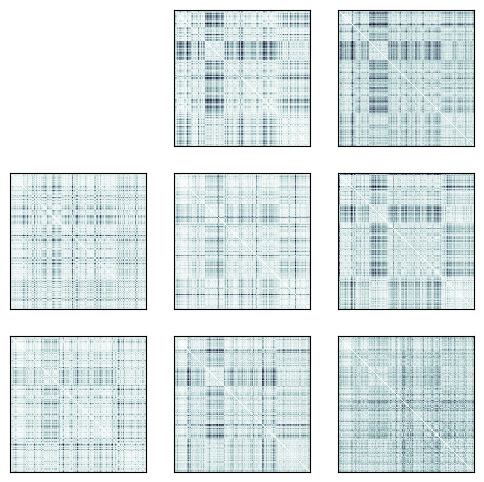

In [7]:
rsatoolbox.vis.show_rdm(rdm_euc)
plt.show()

For this particular application we recommend using crossvalidated distances instead of simple euclidean distance, because the number of presentations varied between stimuli. This will yield a bias in the RDM estimation, which we want to avoid as there is no way of correcting for it later in the analysis. Fortunately, calculating a RDM with crossnobis distance is no more complicated than using the euclidean one:

In [8]:
rdm_no_noise = rsatoolbox.rdm.calc_rdm_unbalanced(
    datasets_v1,
    method='crossnobis',
    descriptor='imagenumber',
    cv_descriptor='run'
)
rdm_no_noise.sort_by(imagenumber='alpha')

/Users/heiko.schutt/miniconda3/envs/rsa/lib/python3.11/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


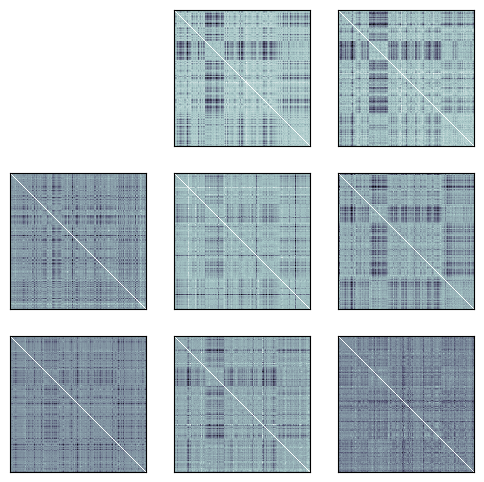

In [9]:
# note that these RDM estimates are indeed substantially different from the euclidean distance estimates!
rsatoolbox.vis.show_rdm(rdm_no_noise)
plt.show()

In [10]:
rdm = rsatoolbox.rdm.calc_rdm_unbalanced(
        datasets_v1,
        method='crossnobis',
        descriptor='imagenumber',
        cv_descriptor='run',
        noise=noise_prec)
rdm.sort_by(imagenumber='alpha')

/Users/heiko.schutt/miniconda3/envs/rsa/lib/python3.11/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


In [11]:
rsatoolbox.vis.show_rdm(rdm.mean())
plt.savefig("rdm_data.svg")

In [12]:
rdm_noise_u = rsatoolbox.rdm.calc_rdm_unbalanced(
        datasets_v1,
        method='mahalanobis',
        descriptor='imagenumber',
        noise=noise_prec)
rdm_noise_u.sort_by(imagenumber='alpha')

/Users/heiko.schutt/miniconda3/envs/rsa/lib/python3.11/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


In [13]:
rdm_noise = rsatoolbox.rdm.calc_rdm(
        datasets_v1,
        method='mahalanobis',
        descriptor='imagenumber',
        noise=noise_prec)
rdm_noise.sort_by(imagenumber='alpha')

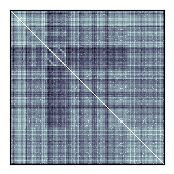

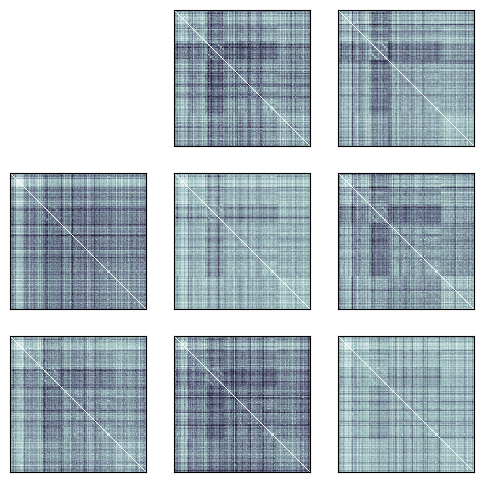

In [14]:
rsatoolbox.vis.show_rdm(rdm_noise_u)
plt.show()

In [15]:
# looking at consistency across subjects
idx = np.triu_indices(len(datasets_v1), 1)
sim_euc = rsatoolbox.rdm.compare(rdm_euc,rdm_euc, method="spearman")
sim_no_noise = rsatoolbox.rdm.compare(rdm_no_noise,rdm_no_noise, method="spearman")
sim_noise = rsatoolbox.rdm.compare(rdm_noise,rdm_noise, method="spearman")
sim = rsatoolbox.rdm.compare(rdm,rdm, method="spearman")

print("The average spearman rank correlation between subjects for the different RDMs were:")
print(f"Euclidean: {np.mean(sim_euc[idx])}")
print(f"Crossvalidated no noise: {np.mean(sim_no_noise[idx])}")
print(f"Only noise: {np.mean(sim_noise[idx])}")
print(f"CrossNobis: {np.mean(sim[idx])}")

The average spearman rank correlation between subjects for the different RDMs were:
Euclidean: 0.31395308113007026
Crossvalidated no noise: 0.23878966489837944
Only noise: 0.6226199937316786
CrossNobis: 0.5624433354366516


## Computing RDM predictions from the DNN

Here we load the pre-trained ResNet-50 model from `torchvision.models`, extract activations for the stimulus images and compute RDMs from these activations.

To do so the first step is to get the DNN:

In [16]:
# Load pre-trained ResNet-50
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.eval()

# Define the preprocessing transform (same as used for ImageNet)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("ResNet-50 model loaded successfully.")

ResNet-50 model loaded successfully.


In [17]:
# Load pre-trained ResNet-50
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.eval()

# Define the preprocessing transform (same as used for ImageNet)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("ResNet-50 model loaded successfully.")

ResNet-50 model loaded successfully.


### Prepare Stimuli Images

Load and preprocess the stimuli images as input for the model.

In [18]:
# Load stimulus images
stimuli_dir = 'paper_example/stimuli'
image_files = sorted([f for f in os.listdir(stimuli_dir) if f.endswith('.png')])

images = [
    preprocess(Image.open(os.path.join(stimuli_dir, img_file)).convert('RGB'))
    for img_file in image_files
]
images = torch.stack(images)  # Shape: (num_images, 3, 224, 224)
print(f"Loaded {len(images)} stimulus images.")

Loaded 284 stimulus images.


### Extract Activations Using Torchlens

There are many methods available to extract internal activations of deep neural networks. Here, we use [torchlens](https://github.com/johnmarktaylor91/torchlens), a particularly user-fiendly tool to explore internal processing of deep neural networks introduced in this [paper](https://www.nature.com/articles/s41598-023-40807-0).

Let's first have a look at what representations one could extract from our ResNet-50. To do so, we create a dummy input x with the right dimensions for one image and apply `visualization.show_model_graph`. This yields an illustration of the model, showing the name of each representation. Based on this graph we need to choose all representations that we want to compare to the fMRI data. Here, we will choose only the outputs of the major blocks ('layer1', 'layer2', 'layer3', and 'layer4'), the pooled 1D representation ('avgpool') and an early convolutional layer out of the stem ('conv1'). 

Other intermediate steps can be accessed equally easy though. For example our 'layer4' choice is synonymous with 'layer4.2', 'relu_49_172' or 'layer4.2.relu:3'. If we wanted to extract the representation one step earlier, we would use 'iadd_16_171'. 

For many comonly used deep neural networks the model graphs to find the names can also be found in torchlens' [Menagery](https://drive.google.com/drive/u/0/folders/1BsM6WPf3eB79-CRNgZejMxjg38rN6VCb) of models.

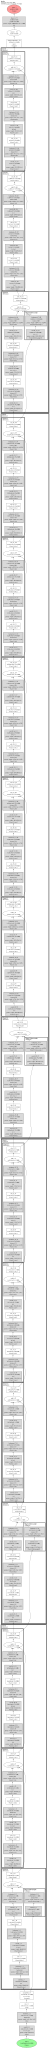

In [19]:
# this code to see a graph summary of ResNet-50 with the names attached to each block
x = torch.rand(1,3,224,224)
tl.visualization.show_model_graph(model, x)


In [20]:
# So these are the layers we want to extract activations for:
layers_to_extract = [
    'conv1',  # After initial conv
    'relu_1_3',  # nonlinearity
    'maxpool',  # stem pooling
    'layer1',  # After layer1 (block1)
    'layer2',  # After layer2 (block2)
    'layer3',  # After layer3 (block3)
    'layer4',  # After layer4 (block4)
    'avgpool',  # After avgpool
]
layer_names = layers_to_extract

Once we chose our layers, we can use a function called `batched_extract` to run the model over our inputs and extract the activations into a dictionary:

In [21]:
activations = tl.batched_extract(
    model,
    stimuli=images,
    layers=layers_to_extract,
    batch_size = 4)

torchlens.extract:   0%|          | 0/71 [00:00<?, ?it/s]

In [22]:
# listing the names and shapes of the extracted activations:
for name, act in activations.items():
    print(f"{name}: {act.shape}")
# convert to numpy arrays if not yet done:
for name, act in activations.items():
    if torch.is_tensor(act):
        activations[name] = activations[name].numpy()

conv1: torch.Size([284, 64, 112, 112])
relu_1_3: torch.Size([284, 64, 112, 112])
maxpool: torch.Size([284, 64, 56, 56])
layer1: torch.Size([284, 256, 56, 56])
layer2: torch.Size([284, 512, 28, 28])
layer3: torch.Size([284, 1024, 14, 14])
layer4: torch.Size([284, 2048, 7, 7])
avgpool: torch.Size([284, 2048, 1, 1])


In [23]:
# by running this cell you can save the activations and don't need to recompute them again:
np.savez('paper_example/resnet50_activations.npz', **activations)

### turn activations into dataset objects and compute RDMs
Now that we have the activations extracted from the network, we can compute RDMs for the different layers the same way as we did for the fMRI data above.

In [24]:
# loading activations if they were saved:
if os.path.exists('paper_example/resnet50_activations.npz'):
    activations = np.load('paper_example/resnet50_activations.npz')
    layer_names = list(activations.keys())

In [25]:
datasets = []
for layer in layer_names:
    print(f"Calculating RDM for layer: {layer}")
    layer_activations = activations[layer].reshape(284, -1)  
    datasets.append(rsatoolbox.data.dataset.Dataset(layer_activations, obs_descriptors={'Image number': np.arange(284)}))

rdms_model = rsatoolbox.rdm.calc_rdm(
    datasets,
    method='euclidean',
    descriptor='Image number')

rdms_model.rdm_descriptors.update({'Layer': layer_names})


Calculating RDM for layer: conv1
Calculating RDM for layer: relu_1_3
Calculating RDM for layer: maxpool
Calculating RDM for layer: layer1
Calculating RDM for layer: layer2
Calculating RDM for layer: layer3
Calculating RDM for layer: layer4
Calculating RDM for layer: avgpool


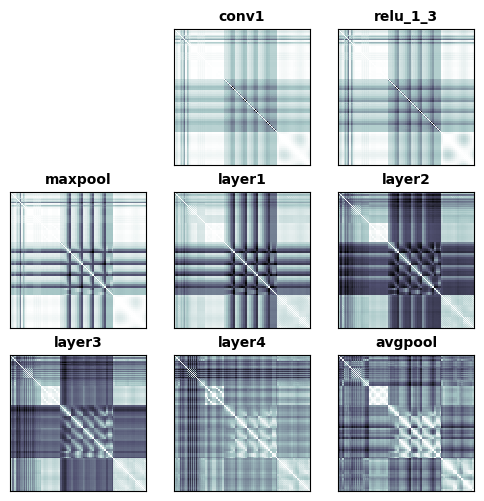

In [26]:
# as for the fMRI rdms, we can display the model RDMs to see that different layers predict quite different RDMs:
rsatoolbox.vis.show_rdm(rdms_model, rdm_descriptor='Layer')
#plt.savefig("model_rdms.svg")
plt.show()

# Run the inference/comparison
To run a comparison between model and data, we need to first construct a RDM model from our model RDMs. Here, we stick to a fixed model, i.e. there are no free parameters to fit. The model layers simply predict the data RDMs to be the same as their RDM:

In [27]:
rsa_models = []
for idx, layer in enumerate(layer_names):
    rsa_models.append(rsatoolbox.model.ModelFixed(rdm=rdms_model[idx], name=layer))

In [28]:
results = rsatoolbox.inference.eval_fixed(rsa_models, rdm, method='cosine_cov')
print(results)

Results for running fixed evaluation for cosine_cov on 8 models:

Model    |   Eval ± SEM   | p (against 0) | p (against NC) |
------------------------------------------------------------
conv1    |  0.235 ± 0.005 |      < 0.001  |       < 0.001  |
relu_1_3 |  0.298 ± 0.006 |      < 0.001  |       < 0.001  |
maxpool  |  0.281 ± 0.022 |      < 0.001  |       < 0.001  |
layer1   |  0.328 ± 0.021 |      < 0.001  |       < 0.001  |
layer2   |  0.358 ± 0.026 |      < 0.001  |       < 0.001  |
layer3   |  0.382 ± 0.032 |      < 0.001  |       < 0.001  |
layer4   |  0.401 ± 0.027 |      < 0.001  |       < 0.001  |
avgpool  |  0.332 ± 0.027 |      < 0.001  |       < 0.001  |

p-values are based on uncorrected t-tests


In [29]:
# computing baseline performance -> performance of a flat RDM of ones
null_rdm = rsatoolbox.rdm.RDMs(np.ones_like(rdm.get_vectors()[0]))
null_perfs = rsatoolbox.rdm.compare(rdm, null_rdm, method="cosine_cov")
m_null = np.mean(null_perfs)
sem_null = np.std(null_perfs) / np.sqrt(len(rdm))

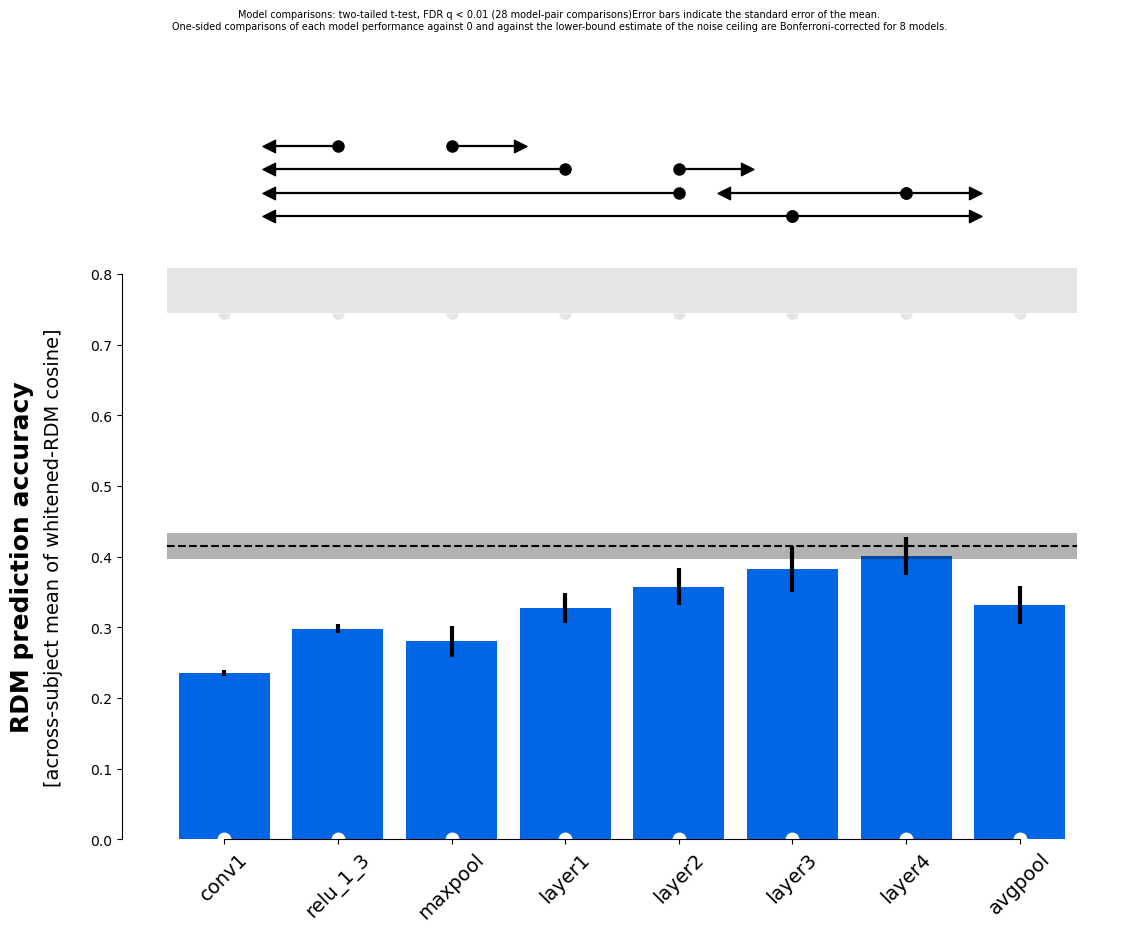

In [30]:
fig, ax1, ax2 = rsatoolbox.vis.plot_model_comparison(results)
ax1.plot([-0.5, 7.5], [m_null, m_null], 'k--')
p = Rectangle([-0.5, m_null-sem_null], 8, 2*sem_null, facecolor='k', alpha=0.3)
ax1.add_artist(p)
plt.savefig("results.svg")
plt.show()